# CNN
Oleh Kelompok 60: JatimBengkulu

| Nama Anggota | NIM |
|--------------|-----|
| Muhammat Izzat Jundy | 13523092 |
| Zulfaqqar Nayaka Athadiansyah | 13523094 |
| Muhammad Adha Ridwan | 13523098 |

Notebook untuk eksperimen dengan Convolutional Neural Networks (CNN) pada dataset Intel Image Classification. Dataset ini berisi gambar dari 6 kelas berbeda: buildings, forest, glacier, mountain, sea, dan street. Notebook ini mencakup proses loading data, preprocessing, pembuatan model CNN, pelatihan, dan evaluasi model. 

NB: Notebook ini awalnya dirancang untuk dijalankan di Kaggle, makanya path dataset dan artifacts disesuaikan dengan lingkungan tersebut. Semua fungsi yang diimplement di local sudah dicopas ke sini.

In [55]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 0. Setup & configurasi

In [2]:
import os, sys, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, f1_score


In [3]:
# NB: ini aslinya dirun di Kaggle:
DATASET_ROOT = Path("/kaggle/input/datasets/puneet6060/intel-image-classification")

# kalo jalanin di local, pake ini:
# DATASET_ROOT = Path(path)

TRAIN_DIR     = DATASET_ROOT / "seg_train" / "seg_train"
TEST_DIR      = DATASET_ROOT / "seg_test" / "seg_test"
VAL_SPLIT     = 0.2

IMG_SIZE   = (150, 150)
BATCH_SIZE = 32
SEED       = 42
EPOCHS     = 20

project_root  = Path.cwd()
ARTIFACTS_DIR  = project_root / "artifacts" / "cnn"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset root : {DATASET_ROOT.exists()}")
print(f"Train dir exists : {TRAIN_DIR.exists()}")
print(f"Test  dir exists : {TEST_DIR.exists()}")


Dataset root : True
Train dir exists : True
Test  dir exists : True


## 1. Bikin utility functions

In [33]:
#pindahan dr img_loaders.py
from PIL import Image
import numpy as np

def load_image(path, target_size = (224,224)):
    with Image.open(path) as img:
        img = img.convert("RGB")
        img = img.resize(target_size)

    img_array = np.array(img).astype(np.float32)
    img_array = img_array / 255.0

    return img_array


In [6]:
#dri batch_loader.py
import numpy as np
from concurrent.futures import ThreadPoolExecutor

def load_batch(paths, target_size=(224, 224), max_workers=8):
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        images = list(ex.map(lambda p: load_image(p, target_size), paths))
    return np.stack(images, axis=0)

In [8]:
#feature_extractor.py
import numpy as np
from tqdm import tqdm
import os

from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

class FeatureExtractor:
    def __init__(self):
        self.model = InceptionV3(weights="imagenet", include_top=False, pooling="avg")

    def extract(self, image_paths, batch_size=32):
        features = []

        for i in tqdm(range(0, len(image_paths), batch_size)):
            batch_paths = image_paths[i:i+batch_size]

            batch = load_batch(batch_paths) * 255.0
            batch = preprocess_input(batch)

            feat = self.model.predict(batch, verbose=0)
            features.append(feat)

        return np.vstack(features)

    def save(self, features, save_path):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        np.save(save_path, features)

    def load(self, path):
        return np.load(path)


## 2. Implementasi Forward Propagation from scratch
NB: ini mostly dicopas dari repo ke Kaggle

In [9]:
#conv2d,py
import numpy as np

class Conv2D:
    def __init__(self, weight, bias, stride = 1, pad = 0, activation=None) -> None:
        self.weight = weight
        self.bias = bias
        self.stride = stride
        self.pad = pad
        self.activation = activation

    def forward(self, x):
        if x.ndim == 3:
            return self._forward_batch(x[np.newaxis])[0]
        elif x.ndim == 4:
            return self._forward_batch(x)
        else:
            raise ValueError("Input must have shape (H,W,C) or (N,H,W,C)")

    def _forward_batch(self, x):
        N, H, W, C_in = x.shape
        kH, kW, _, C_out = self.weight.shape

        if self.pad > 0:
            x = np.pad(x, ((0,0),(self.pad,self.pad),(self.pad,self.pad),(0,0)), mode="constant")

        _, H_pad, W_pad, _ = x.shape
        H_out = (H_pad - kH) // self.stride + 1
        W_out = (W_pad - kW) // self.stride + 1

        shape   = (N, H_out, W_out, kH, kW, C_in)
        strides = (
            x.strides[0],
            x.strides[1] * self.stride,
            x.strides[2] * self.stride,
            x.strides[1],
            x.strides[2],
            x.strides[3],
        )
        patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
        col = patches.reshape(N, H_out, W_out, -1)

        W_col = self.weight.reshape(-1, C_out)

        out = col @ W_col + self.bias

        if self.activation is not None:
            out = self.activation(out)

        return out.astype(np.float32)

In [10]:
#locallyconnected2d.py
import numpy as np


class LocallyConnected2D:
    def __init__(self, weight, bias, kernel_size, stride=1, pad=0, activation=None):
        self.weight = weight
        self.bias = bias
        self.kernel_size = kernel_size
        self.stride = stride
        self.pad = pad
        self.activation = activation

    def forward(self, x):
        if x.ndim == 3:
            return self._forward_batch(x[np.newaxis])[0]
        elif x.ndim == 4:
            return self._forward_batch(x)
        raise ValueError("Input must have shape (H, W, C) or (N, H, W, C)")


    def _forward_batch(self, x):
        N, H, W, C_in = x.shape
        kH, kW = self.kernel_size

        if self.pad > 0:
            x = np.pad(x, ((0,0),(self.pad,self.pad),(self.pad,self.pad),(0,0)), mode="constant")

        _, H_pad, W_pad, _ = x.shape
        H_out = (H_pad - kH) // self.stride + 1
        W_out = (W_pad - kW) // self.stride + 1
        num_locations = H_out * W_out

        shape   = (N, H_out, W_out, kH, kW, C_in)
        strides = (
            x.strides[0],
            x.strides[1] * self.stride,
            x.strides[2] * self.stride,
            x.strides[1],
            x.strides[2],
            x.strides[3],
        )
        patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
        col = patches.reshape(N, num_locations, -1)

        out = np.einsum('nli,lio->nlo', col, self.weight, optimize=True)

        if self.bias.ndim == 2:
            out = out + self.bias
        else:
            out = out + self.bias

        out = out.reshape(N, H_out, W_out, -1)

        if self.activation is not None:
            out = self.activation(out)

        return out.astype(np.float32)

In [11]:
#poolinng.py
import numpy as np


class MaxPooling2D:
    def __init__(self, pool_size=2, stride=None):
        self.pool_size = pool_size if isinstance(pool_size, tuple) else (pool_size, pool_size)
        self.stride    = stride if stride is not None else self.pool_size
        self.stride    = self.stride if isinstance(self.stride, tuple) else (self.stride, self.stride)

    def forward(self, x):
        if x.ndim == 3:
            return self._forward_batch(x[np.newaxis])[0]
        elif x.ndim == 4:
            return self._forward_batch(x)
        raise ValueError("Input must have shape (H, W, C) or (N, H, W, C)")

    def _forward_batch(self, x):
        N, H, W, C = x.shape
        pH, pW = self.pool_size
        sH, sW = self.stride
        H_out = (H - pH) // sH + 1
        W_out = (W - pW) // sW + 1

        shape   = (N, H_out, W_out, pH, pW, C)
        strides = (
            x.strides[0],
            x.strides[1] * sH,
            x.strides[2] * sW,
            x.strides[1],
            x.strides[2],
            x.strides[3],
        )
        patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
        return patches.max(axis=(3, 4)).astype(x.dtype)


class AveragePooling2D:
    def __init__(self, pool_size=2, stride=None):
        self.pool_size = pool_size if isinstance(pool_size, tuple) else (pool_size, pool_size)
        self.stride    = stride if stride is not None else self.pool_size
        self.stride    = self.stride if isinstance(self.stride, tuple) else (self.stride, self.stride)

    def forward(self, x):
        if x.ndim == 3:
            return self._forward_batch(x[np.newaxis])[0]
        elif x.ndim == 4:
            return self._forward_batch(x)
        raise ValueError("Input must have shape (H, W, C) or (N, H, W, C)")

    def _forward_batch(self, x):
        N, H, W, C = x.shape
        pH, pW = self.pool_size
        sH, sW = self.stride
        H_out = (H - pH) // sH + 1
        W_out = (W - pW) // sW + 1

        shape   = (N, H_out, W_out, pH, pW, C)
        strides = (
            x.strides[0],
            x.strides[1] * sH,
            x.strides[2] * sW,
            x.strides[1],
            x.strides[2],
            x.strides[3],
        )
        patches = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
        return patches.mean(axis=(3, 4)).astype(x.dtype)


In [12]:
#global__pooling.py
import numpy as np


class GlobalMaxPooling2D:
    def forward(self, x):
        if x.ndim == 3:
            return self._forward(x)

        if x.ndim == 4:
            return np.stack([self._forward(img) for img in x], axis=0)

        raise ValueError("Input must have shape (H, W, C) or (N, H, W, C)")

    def _forward(self, x):
        return np.max(x, axis=(0, 1))


class GlobalAveragePooling2D:
    def forward(self, x): 
        if x.ndim == 3:
            return self._forward(x)

        if x.ndim == 4:
            return np.stack([self._forward(img) for img in x], axis=0)

        raise ValueError("Input must have shape (H, W, C) or (N, H, W, C)")

    def _forward(self, x):
        return np.mean(x, axis=(0, 1))


In [13]:
#flatten.py
import numpy as np


class Flatten:
    def forward(self, x):
        if x.ndim == 3:
            return x.reshape(-1)
        elif x.ndim == 4:
            return x.reshape(x.shape[0], -1)
        raise ValueError("Input must have shape (H, W, C) or (N, H, W, C)")

In [14]:
#dense.py
import numpy as np

class Dense:
    def __init__(self, weights, bias, activation=None):
        self.weights = weights
        self.bias = bias
        self.activation = activation

    def forward(self, x):
        if x.ndim == 1:
            out = self._forward(x)
        elif x.ndim == 2:
            out = np.stack([self._forward(sample) for sample in x], axis=0)
        else:
            raise ValueError("Input must have shape (in_features,) or (N, in_features)")

        if self.activation is not None:
            out = self.activation(out)

        return out

    def _forward(self, x):
        return x @ self.weights + self.bias


In [16]:
#activatipn.py
import numpy as np

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)


## 3. Training Model

### Persiapan

In [17]:
def build_dataset(data_dir, shuffle=True, subset=None, validation_split=None):
    kwargs = {
        "labels"          : "inferred",
        "label_mode"      : "categorical",
        "image_size"      : IMG_SIZE,
        "batch_size"      : BATCH_SIZE,
        "shuffle"         : shuffle,
        "seed"            : SEED,
    }
    if subset is not None:
        kwargs["validation_split"] = validation_split
        kwargs["subset"]           = subset
    return tf.keras.utils.image_dataset_from_directory(data_dir, **kwargs)

In [19]:
train_ds = build_dataset(TRAIN_DIR, shuffle=True,  subset="training",   validation_split=VAL_SPLIT)
val_ds   = build_dataset(TRAIN_DIR, shuffle=True,  subset="validation", validation_split=VAL_SPLIT)
test_ds  = build_dataset(TEST_DIR,  shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

print("klas:", class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
klas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


### Model Keras (Conv2D)

In [21]:
def build_cnn(
    input_shape     = (150, 150, 3),
    num_classes     = 6,
    filters         = (32, 64, 128),
    kernel_size     = 3,
    pooling_type    = "max",
    dense_units     = 128,
    use_global_pooling = False,
    dropout_rate    = 0.3,
):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)

    for f in filters:
        x = layers.Conv2D(f, kernel_size, padding="same", activation="relu")(x)
        if pooling_type == "avg":
            x = layers.AveragePooling2D(pool_size=2)(x)
        else:
            x = layers.MaxPooling2D(pool_size=2)(x)
        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    if use_global_pooling:
        x = layers.GlobalAveragePooling2D()(x)
    else:
        x = layers.Flatten()(x)

    if dropout_rate and dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    x       = layers.Dense(dense_units, activation="relu")(x)
    if dropout_rate and dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)

### Variasi hiperparameter

In [22]:
# 2 variasi jumlah layer
num_layers_options = [2, 3]

# 2 variasi filter per layer
filter_configs = [
    {2: (32, 64),         3: (32, 64, 128)}, 
    {2: (64, 128),        3: (64, 128, 256)},
]

# 2 variasi kernel
kernel_size_options = [3, 5]

# 2 variasi pooling
pooling_type_options = ["max", "avg"]

In [23]:
experiment_configs = []
idx = 1

for num_layers in num_layers_options:
    for filter_config in filter_configs:
        filters = filter_config[num_layers]
        for kernel_size in kernel_size_options:
            for pooling_type in pooling_type_options:
                tag = f"exp_{idx:02d}_L{num_layers}_K{kernel_size}_pool{pooling_type[0].upper()}"
                
                config = {
                    "tag"                : tag,
                    "filters"            : filters,
                    "kernel_size"        : kernel_size,
                    "pooling_type"       : pooling_type,
                    "dense_units"        : 128,
                    "use_global_pooling" : False,
                }
                experiment_configs.append(config)
                idx += 1

experiments_dir = ARTIFACTS_DIR / "experiments"
experiments_dir.mkdir(parents=True, exist_ok=True)

print(f"Total eksperimen: {len(experiment_configs)}")
for cfg in experiment_configs:
    print(f"  {cfg['tag']}: filters={cfg['filters']}, kernel={cfg['kernel_size']}, pooling={cfg['pooling_type']}")

Total eksperimen: 16
  exp_01_L2_K3_poolM: filters=(32, 64), kernel=3, pooling=max
  exp_02_L2_K3_poolA: filters=(32, 64), kernel=3, pooling=avg
  exp_03_L2_K5_poolM: filters=(32, 64), kernel=5, pooling=max
  exp_04_L2_K5_poolA: filters=(32, 64), kernel=5, pooling=avg
  exp_05_L2_K3_poolM: filters=(64, 128), kernel=3, pooling=max
  exp_06_L2_K3_poolA: filters=(64, 128), kernel=3, pooling=avg
  exp_07_L2_K5_poolM: filters=(64, 128), kernel=5, pooling=max
  exp_08_L2_K5_poolA: filters=(64, 128), kernel=5, pooling=avg
  exp_09_L3_K3_poolM: filters=(32, 64, 128), kernel=3, pooling=max
  exp_10_L3_K3_poolA: filters=(32, 64, 128), kernel=3, pooling=avg
  exp_11_L3_K5_poolM: filters=(32, 64, 128), kernel=5, pooling=max
  exp_12_L3_K5_poolA: filters=(32, 64, 128), kernel=5, pooling=avg
  exp_13_L3_K3_poolM: filters=(64, 128, 256), kernel=3, pooling=max
  exp_14_L3_K3_poolA: filters=(64, 128, 256), kernel=3, pooling=avg
  exp_15_L3_K5_poolM: filters=(64, 128, 256), kernel=5, pooling=max
  exp_1

In [24]:
y_true_onehot = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

y_true = np.argmax(y_true_onehot, axis=1) 
print(f"Test set size: {len(y_true)}")

Test set size: 3000


In [25]:
experiment_results = []

for idx, cfg in enumerate(experiment_configs, start=1):
    print(f"\n[{idx}/{len(experiment_configs)}] {cfg['tag']} ...")

    exp_model = build_cnn(
        input_shape        = IMG_SIZE + (3,),
        num_classes        = NUM_CLASSES,
        filters            = cfg["filters"],
        kernel_size        = cfg["kernel_size"],
        pooling_type       = cfg["pooling_type"],
        dense_units        = cfg["dense_units"],
        use_global_pooling = cfg["use_global_pooling"],
    )

    exp_model.compile(
        optimizer = keras.optimizers.Adam(),
        loss      = keras.losses.CategoricalCrossentropy(),
        metrics   = [
            "accuracy",
            keras.metrics.F1Score(average="macro", name="f1_macro"),
        ],
    )

    t0 = time.perf_counter()
    exp_hist = exp_model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = EPOCHS,
        callbacks       = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=2, restore_best_weights=True
            )
        ],
        verbose = 1,
    )
    train_time_sec = time.perf_counter() - t0

    y_pred_proba = exp_model.predict(test_ds, verbose=0)
    y_pred_exp   = np.argmax(y_pred_proba, axis=1)

    test_f1_macro = f1_score(y_true, y_pred_exp, average="macro")

    val_acc    = max(exp_hist.history["val_accuracy"])
    val_f1     = max(exp_hist.history["val_f1_macro"])

    # save
    weights_path = experiments_dir / f"{cfg['tag']}.weights.h5"
    exp_model.save_weights(weights_path)

    result = {
        **{k: v for k, v in cfg.items() if k != "tag"},
        "tag"               : cfg["tag"],
        "val_acc"           : float(val_acc),
        "val_f1_macro"      : float(val_f1),
        "test_f1_macro"     : float(test_f1_macro),
        "train_loss"        : exp_hist.history["loss"],
        "val_loss"          : exp_hist.history["val_loss"],
        "train_time_sec"    : float(train_time_sec),
        "weights_path"      : str(weights_path),
    }
    experiment_results.append(result)
    print(
        f"  val_acc={val_acc:.4f}  val_f1={val_f1:.4f}  "
        f"test_f1={test_f1_macro:.4f}  time={train_time_sec:.0f}s"
    )

results_path = experiments_dir / "experiment_results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(experiment_results, f, indent=2)
print("\nHasil eksperimen disimpan ke", results_path)


[1/16] exp_01_L2_K3_poolM ...
Epoch 1/20


I0000 00:00:1778896042.381753     146 service.cc:152] XLA service 0x7a021c0057b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778896042.381800     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778896042.381807     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778896042.777245     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-16 01:47:24.633146: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 01:47:24.780661: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  5/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.1887 - f1_macro: 0.1560 - loss: 3.9829

I0000 00:00:1778896048.543142     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4607 - f1_macro: 0.4382 - loss: 1.5068

...

351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 75ms/step - accuracy: 0.3670 - f1_macro: 0.3439 - loss: 2.3104 - val_accuracy: 0.6098 - val_f1_macro: 0.6032 - val_loss: 1.0086
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.6235 - f1_macro: 0.6205 - loss: 0.9595 - val_accuracy: 0.6939 - val_f1_macro: 0.6996 - val_loss: 0.8377
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.7099 - f1_macro: 0.7099 - loss: 0.7755 - val_accuracy: 0.7113 - val_f1_macro: 0.7167 - val_loss: 0.7868
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.7457 - f1_macro: 0.7464 - loss: 0.6778 - val_accuracy: 0.7473 - val_f1_macro: 0.7465 - val_loss: 0.6823
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.7908 - f1_macro: 0.7924 - loss: 0.5751 - val_accuracy: 0.7719 - val_f1_macro: 0.7726 - val_loss: 0.6700
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.8193 - f1_macro: 0.8212 - loss: 0.4924 - val_accuracy: 0.7798 - val_f1_macro: 0.779

2026-05-16 01:57:01.819201: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 01:57:01.996142: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


350/351 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4467 - f1_macro: 0.4309 - loss: 1.6018

2026-05-16 01:57:31.383820: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-16 01:57:31.559386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 101ms/step - accuracy: 0.4473 - f1_macro: 0.4316 - loss: 1.5993 - val_accuracy: 0.6393 - val_f1_macro: 0.6421 - val_loss: 0.9250
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.6554 - f1_macro: 0.6546 - loss: 0.9288 - val_accuracy: 0.7103 - val_f1_macro: 0.7128 - val_loss: 0.7826
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.7187 - f1_macro: 0.7194 - loss: 0.7811 - val_accuracy: 0.7160 - val_f1_macro: 0.7161 - val_loss: 0.7830
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.7441 - f1_macro: 0.7449 - loss: 0.6864 - val_accuracy: 0.7498 - val_f1_macro: 0.7524 - val_loss: 0.6939
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.7885 - f1_macro: 0.7899 - loss: 0.5645 - val_accuracy: 0.7523 - val_f1_macro: 0.7509 - val_loss: 0.7525
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.8189 - f1_macro: 0.8206 - loss: 0.4884 - val_accuracy: 0.7744 - val_f1_macro: 0.77

In [26]:
df_results = pd.DataFrame(experiment_results).sort_values("test_f1_macro", ascending=False)
display(df_results[[
    "tag", "filters", "kernel_size", "pooling_type",
    "use_global_pooling", "val_acc", "val_f1_macro", "test_f1_macro", "train_time_sec"
]])

,tag,filters,kernel_size,pooling_type,use_global_pooling,val_acc,val_f1_macro,test_f1_macro,train_time_sec
13,exp_14_L3_K3_poolA,"(64, 128, 256)",3,avg,False,0.828225,0.830133,0.819436,173.905057
10,exp_11_L3_K5_poolM,"(32, 64, 128)",5,max,False,0.817890,0.818473,0.815757,127.095176
14,exp_15_L3_K5_poolM,"(64, 128, 256)",5,max,False,0.814326,0.816154,0.811069,264.299858
0,exp_01_L2_K3_poolM,"(32, 64)",3,max,False,0.801853,0.804071,0.807133,95.648607
9,exp_10_L3_K3_poolA,"(32, 64, 128)",3,avg,False,0.815752,0.818557,0.802848,89.930074
12,exp_13_L3_K3_poolM,"(64, 128, 256)",3,max,False,0.806130,0.808599,0.798730,202.333907
11,exp_12_L3_K5_poolA,"(32, 64, 128)",5,avg,False,0.800428,0.801519,0.796307,117.473336
2,exp_03_L2_K5_poolM,"(32, 64)",5,max,False,0.777263,0.779045,0.791642,109.366579
15,exp_16_L3_K5_poolA,"(64, 128, 256)",5,avg,False,0.777263,0.779045,0.783591,190.855393
8,exp_09_L3_K3_poolM,"(32, 64, 128)",3,max,False,0.769066,0.772796,0.779251,64.841836


## 4. Eksperimen & evaluasi

### helper functions

In [66]:
def get_keras_layer_weights(keras_model):
    layers_info = []
    for layer in keras_model.layers:
        cls = layer.__class__.__name__
        w   = layer.get_weights()
        cfg = layer.get_config()
        layers_info.append((cls, cfg, w))
    return layers_info


def build_scratch_model_shared(layers_info):
    pipeline = []
    for cls, cfg, w in layers_info:
        if cls == "Rescaling":
            scale  = cfg["scale"]       
            offset = cfg["offset"]      
            pipeline.append(("rescaling", scale, offset))

        elif cls == "Conv2D":
            kernel, bias = w[0], w[1]    # shape tuh: (kH, kW, C_in, C_out), (C_out,)
            padding = cfg["padding"]    
            strides = cfg["strides"][0]  # asumsikan strides sama di H & W
            pad_val = kernel.shape[0] // 2 if padding == "same" else 0
            layer   = Conv2D(
                weight=kernel, bias=bias,
                stride=strides, pad=pad_val,
                activation=relu,         # semua conv hrsnya pakai relu di build_cnn
            )
            pipeline.append(("conv2d", layer))

        elif cls == "MaxPooling2D":
            pool_size = cfg["pool_size"][0]
            layer = MaxPooling2D(pool_size=pool_size)
            pipeline.append(("pool", layer))

        elif cls == "AveragePooling2D":
            pool_size = cfg["pool_size"][0]
            layer = AveragePooling2D(pool_size=pool_size)
            pipeline.append(("pool", layer))

        elif cls == "GlobalAveragePooling2D":
            pipeline.append(("pool", GlobalAveragePooling2D()))

        elif cls == "GlobalMaxPooling2D":
            pipeline.append(("pool", GlobalMaxPooling2D()))

        elif cls == "Flatten":
            pipeline.append(("flatten", Flatten()))

        elif cls == "Dense":
            kernel, bias = w[0], w[1]
            act_name = cfg["activation"]
            act_fn   = softmax if act_name == "softmax" else (relu if act_name == "relu" else None)
            layer    = Dense(weights=kernel, bias=bias, activation=act_fn)
            pipeline.append(("dense", layer))

        elif cls == "Dropout":
            pass   # skip klo inference

    return pipeline

# sbnrnya ini sama kyk shared, tp ganti jd locallyconnected. bobot conv2d keras gbs langsung dipake sih
# diasumsiin layers_info udah dari model LocallyConnected2D Keras
def build_scratch_model_nonshared(layers_info):
    pipeline = []
    for cls, cfg, w in layers_info:
        if cls == "Rescaling":
            pass #udah dihandle load_image soalnya, dah dibagi 255

        elif cls == "LocallyConnected2DKeras":
            # Keras LocallyConnected2D menyimpan kernel shape (output_h*output_w, kH*kW*C_in, C_out)
            # dan bias shape (output_h*output_w, C_out) atau (C_out,)
            kernel, bias = w[0], w[1]
            kernel_size  = tuple(cfg["kernel_size"])
            strides      = cfg["stride"]
            layer = LocallyConnected2D(
                weight=kernel, bias=bias,
                kernel_size=kernel_size, stride=strides, pad=0,
                activation=relu,
            )
            pipeline.append(("lc2d", layer))

        elif cls == "MaxPooling2D":
            pool_size = cfg["pool_size"][0]
            pipeline.append(("pool", MaxPooling2D(pool_size=pool_size)))

        elif cls == "AveragePooling2D":
            pool_size = cfg["pool_size"][0]
            pipeline.append(("pool", AveragePooling2D(pool_size=pool_size)))

        elif cls == "GlobalAveragePooling2D":
            pipeline.append(("pool", GlobalAveragePooling2D()))

        elif cls == "Flatten":
            pipeline.append(("flatten", Flatten()))

        elif cls == "Dense":
            kernel, bias = w[0], w[1]
            act_name = cfg["activation"]
            act_fn   = softmax if act_name == "softmax" else (relu if act_name == "relu" else None)
            pipeline.append(("dense", Dense(weights=kernel, bias=bias, activation=act_fn)))

        elif cls == "Dropout":
            pass

    return pipeline


def run_pipeline(pipeline, x):
    for item in pipeline:
        kind = item[0]
        if kind == "rescaling":
            _, scale, offset = item
            x = x.astype(np.float32) * scale + offset
        else:
            _, layer = item
            x = layer.forward(x)
    return x

### ambil config paling mantap

In [35]:
best_cfg = max(experiment_results, key=lambda r: r["test_f1_macro"])
print("Model terbaik :", best_cfg["tag"])
print(f"  test_f1_macro = {best_cfg['test_f1_macro']:.4f}")
print(f"  filters       = {best_cfg['filters']}")
print(f"  kernel_size   = {best_cfg['kernel_size']}")
print(f"  pooling_type  = {best_cfg['pooling_type']}")

Model terbaik : exp_14_L3_K3_poolA
  test_f1_macro = 0.8194
  filters       = (64, 128, 256)
  kernel_size   = 3
  pooling_type  = avg


### rebuild best model

In [36]:
best_keras_model = build_cnn(
    input_shape        = IMG_SIZE + (3,),
    num_classes        = NUM_CLASSES,
    filters            = tuple(best_cfg["filters"]),
    kernel_size        = best_cfg["kernel_size"],
    pooling_type       = best_cfg["pooling_type"],
    dense_units        = best_cfg["dense_units"],
    use_global_pooling = best_cfg["use_global_pooling"],
)
best_keras_model.load_weights(best_cfg["weights_path"])
best_keras_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_17 (Rescaling)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_23            │ (None, 75, 75, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_24            │ (None, 37, 37, 128)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_25            │ (None, 18, 18, 256)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,988,550 (41.92 MB)

 Trainable params: 10,988,550 (41.92 MB)

 Non-trainable params: 0 (0.00 B)

## Kumpulin semua path gambatr test & label

In [37]:
test_image_paths = []
test_labels      = []

for class_idx, class_name in enumerate(class_names):
    class_dir = TEST_DIR / class_name
    for img_path in sorted(class_dir.glob("*.jpg")):
        test_image_paths.append(img_path)
        test_labels.append(class_idx)

y_true_scratch = np.array(test_labels)
print(f"Total gambar test : {len(test_image_paths)}")
print(f"Distribusi kelas  : {dict(zip(*np.unique(y_true_scratch, return_counts=True)))}")

Total gambar test : 3000
Distribusi kelas  : {np.int64(0): np.int64(437), np.int64(1): np.int64(474), np.int64(2): np.int64(553), np.int64(3): np.int64(525), np.int64(4): np.int64(510), np.int64(5): np.int64(501)}


## 4A. Forward Propagation from Scratch yg Shared (Conv2D)

In [38]:
# predict helper pke load_batch dari Bagian 1 
def predict_scratch(pipeline, image_paths, target_size, batch_size=32):
    all_probs = []
    n_batches = -(-len(image_paths) // batch_size)
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i : i + batch_size]
        # load_batch dari Bagian 1: PIL resize + normalize ke [0,1]
        batch_imgs  = load_batch(batch_paths, target_size=target_size)
        probs       = run_pipeline(pipeline, batch_imgs)   # (N, num_classes)
        all_probs.append(probs)
        print(f"  batch {i // batch_size + 1}/{n_batches}", end="\r")
    print()
    return np.concatenate(all_probs, axis=0)


In [39]:
# Build pipeline shared dari bobot best Keras model
layers_info_shared = get_keras_layer_weights(best_keras_model)
pipeline_shared    = build_scratch_model_shared(layers_info_shared)

print("Menjalankan forward propagation scratch (shared / Conv2D)...")
t0 = time.perf_counter()
probs_shared  = predict_scratch(pipeline_shared, test_image_paths, IMG_SIZE, batch_size=32)
time_shared   = time.perf_counter() - t0

y_pred_shared = np.argmax(probs_shared, axis=1)
f1_shared     = f1_score(y_true_scratch, y_pred_shared, average="macro")

print(f"[Scratch Shared/Conv2D]")
print(f"  Macro F1 = {f1_shared:.4f}  |  waktu inference = {time_shared:.1f}s")
print()
print(classification_report(y_true_scratch, y_pred_shared, target_names=class_names))


Menjalankan forward propagation scratch (shared / Conv2D)...
  batch 94/94
[Scratch Shared/Conv2D]
  Macro F1 = 0.8186  |  waktu inference = 154.1s

              precision    recall  f1-score   support

   buildings       0.80      0.76      0.78       437
      forest       0.97      0.92      0.94       474
     glacier       0.80      0.80      0.80       553
    mountain       0.77      0.75      0.76       525
         sea       0.78      0.83      0.80       510
      street       0.81      0.85      0.83       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



## 4B. Adu antara Keras vs from scratch (shared)

In [41]:
t0 = time.perf_counter()
probs_keras  = best_keras_model.predict(test_ds, verbose=0)
time_keras   = time.perf_counter() - t0

y_pred_keras = np.argmax(probs_keras, axis=1)
f1_keras     = f1_score(y_true, y_pred_keras, average="macro")

print(f"{'':30s} {'Keras':>10s} {'Scratch':>10s}")
print(f"{'Macro F1 (test)':30s} {f1_keras:>10.4f} {f1_shared:>10.4f}")
print(f"{'Waktu inference (s)':30s} {time_keras:>10.1f} {time_shared:>10.1f}")
print(f"{'Selisih F1':30s} {abs(f1_keras - f1_shared):>10.6f}")


                                    Keras    Scratch
Macro F1 (test)                    0.8194     0.8186
Waktu inference (s)                   1.8      154.1
Selisih F1                       0.000879


## 4C. build & train model Non-Shared (LocallyConnected2D)

In [57]:
def build_cnn_lc(
    input_shape        = (32, 32, 3),
    num_classes        = 6,
    filters            = (16, 32),
    kernel_size        = 3,
    pooling_type       = "max",
    dense_units        = 128,
    use_global_pooling = False,
    dropout_rate       = 0.3,
):
    #sbnrnya mirip-mirip sama conv2d
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)

    for f in filters:
        x = LocallyConnected2DKeras(f, kernel_size, activation="relu")(x)
        if pooling_type == "avg":
            x = layers.AveragePooling2D(pool_size=2)(x)
        else:
            x = layers.MaxPooling2D(pool_size=2)(x)
        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    if use_global_pooling:
        x = layers.GlobalAveragePooling2D()(x)
    else:
        x = layers.Flatten()(x)

    if dropout_rate and dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    x       = layers.Dense(dense_units, activation="relu")(x)
    if dropout_rate and dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)


In [49]:
#bikin custom layer keras locally connected 2d soalnya udah dihapus di Keras versi 3
class LocallyConnected2DKeras(keras.layers.Layer):
    def __init__(self, filters, kernel_size, stride=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.filters     = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride      = stride
        self.activation  = keras.activations.get(activation)

    def build(self, input_shape):
        _, H, W, C_in = input_shape
        kH, kW = self.kernel_size
        H_out = (H - kH) // self.stride + 1
        W_out = (W - kW) // self.stride + 1
        self.H_out = H_out
        self.W_out = W_out
        num_locations = H_out * W_out
        patch_size    = kH * kW * C_in

        self.w = self.add_weight(
            name="kernel",
            shape=(num_locations, patch_size, self.filters),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.b = self.add_weight(
            name="bias",
            shape=(num_locations, self.filters),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        kH, kW = self.kernel_size
        patches = tf.image.extract_patches(
            images=x,
            sizes=[1, kH, kW, 1],
            strides=[1, self.stride, self.stride, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        N        = tf.shape(patches)[0]
        col      = tf.reshape(patches, (N, self.H_out * self.W_out, -1))
        out      = tf.einsum('nli,lio->nlo', col, self.w) + self.b
        out      = tf.reshape(out, (N, self.H_out, self.W_out, self.filters))
        return self.activation(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update(filters=self.filters, kernel_size=self.kernel_size,
                   stride=self.stride, activation=keras.activations.serialize(self.activation))
        return cfg

#### Resize dulu

In [59]:
lc_img_size = (32, 32)

train_ds_lc = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode="categorical", image_size=lc_img_size,
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED, validation_split=VAL_SPLIT, subset="training"
).prefetch(tf.data.AUTOTUNE)

val_ds_lc = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode="categorical", image_size=lc_img_size,
    batch_size=BATCH_SIZE, shuffle=True, seed=SEED, validation_split=VAL_SPLIT, subset="validation"
).prefetch(tf.data.AUTOTUNE)

test_ds_lc = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, label_mode="categorical", image_size=lc_img_size,
    batch_size=BATCH_SIZE, shuffle=False
).prefetch(tf.data.AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


#### build &train

In [61]:
lc_model = build_cnn_lc(
    input_shape        = (32, 32, 3),
    num_classes        = NUM_CLASSES,
    filters            = tuple(best_cfg["filters"]),
    kernel_size        = best_cfg["kernel_size"],
    pooling_type       = best_cfg["pooling_type"],
    dense_units        = best_cfg["dense_units"],
    use_global_pooling = best_cfg["use_global_pooling"],
)
lc_model.compile(
    optimizer = keras.optimizers.Adam(),
    loss      = keras.losses.CategoricalCrossentropy(),
    metrics   = ["accuracy", keras.metrics.F1Score(average="macro", name="f1_macro")],
)
lc_model.summary()

t0 = time.perf_counter()
lc_hist = lc_model.fit(
    train_ds_lc, 
    validation_data=val_ds_lc,
    epochs          = EPOCHS,
    callbacks       = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
    ],
    verbose = 1,
)
time_lc_train = time.perf_counter() - t0

lc_weights_path = ARTIFACTS_DIR / "best_lc.weights.h5"
lc_model.save_weights(lc_weights_path)
print(f"\nSelesai ({time_lc_train:.0f}s). Bobot disimpan ke {lc_weights_path}")


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_24 (Rescaling)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_keras_11    │ (None, 30, 30, 64)     │     1,612,800 │
│ (LocallyConnected2DKeras)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_33            │ (None, 15, 15, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_91 (Dropout)            │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_keras_12    │ (None, 13, 13, 128)    │    12,481,664 │
│ (LocallyConnected2DKeras)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_34            │ (None, 6, 6, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_92 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ locally_connected2d_keras_13    │ (None, 4, 4, 256)      │     4,722,688 │
│ (LocallyConnected2DKeras)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_35            │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_94 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,949,126 (72.29 MB)

 Trainable params: 18,949,126 (72.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.3007 - f1_macro: 0.2697 - loss: 1.6241 - val_accuracy: 0.4914 - val_f1_macro: 0.4575 - val_loss: 1.2789
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4827 - f1_macro: 0.4493 - loss: 1.3236 - val_accuracy: 0.4975 - val_f1_macro: 0.4564 - val_loss: 1.2390
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5247 - f1_macro: 0.5029 - loss: 1.2260 - val_accuracy: 0.5609 - val_f1_macro: 0.5487 - val_loss: 1.1355
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5411 - f1_macro: 0.5256 - loss: 1.1752 - val_accuracy: 0.5734 - val_f1_macro: 0.5428 - val_loss: 1.0823
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5701 - f1_macro: 0.5562 - loss: 1.1198 - val_accuracy: 0.6033 - val_f1_macro: 0.5937 - val_loss: 1.0352
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5903 - f1_macro: 0.5814 - loss: 1.0731 - val_accuracy: 0.6162 - val_f1_macro:

## 4D. Forward Propagation Scratch Non-Shared (LocallyConnected2D)

In [67]:
layers_info_lc = get_keras_layer_weights(lc_model)
pipeline_lc    = build_scratch_model_nonshared(layers_info_lc)

print("Menjalankan forward propagation scratch (non-shared / LocallyConnected2D)...")
t0 = time.perf_counter()
probs_lc = predict_scratch(pipeline_lc, test_image_paths, target_size=(32, 32), batch_size=32)
time_lc    = time.perf_counter() - t0

y_pred_lc  = np.argmax(probs_lc, axis=1)
f1_lc      = f1_score(y_true_scratch, y_pred_lc, average="macro")

print(f"Macro F1 = {f1_lc:.4f}")
print(f"waktu inference = {time_lc:.1f}s")
print()
print(classification_report(y_true_scratch, y_pred_lc, target_names=class_names))


Menjalankan forward propagation scratch (non-shared / LocallyConnected2D)...
  batch 94/94
Macro F1 = 0.4255
waktu inference = 52.0s

              precision    recall  f1-score   support

   buildings       0.29      0.70      0.41       437
      forest       1.00      0.11      0.19       474
     glacier       0.48      0.70      0.57       553
    mountain       0.55      0.47      0.51       525
         sea       0.67      0.24      0.35       510
      street       0.53      0.50      0.52       501

    accuracy                           0.46      3000
   macro avg       0.59      0.45      0.43      3000
weighted avg       0.59      0.46      0.43      3000



## 4E. Perbandingan Shared vs Non-Shared

In [71]:
# Keras LC untuk inference time comparison
t0 = time.perf_counter()
probs_lc_keras = lc_model.predict(test_ds_lc, verbose=0)
time_lc_keras  = time.perf_counter() - t0

y_true_lc = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_ds_lc], axis=0)
f1_lc_keras = f1_score(y_true_lc, np.argmax(probs_lc_keras, axis=1), average="macro")

params_shared    = best_keras_model.count_params()
params_nonshared = lc_model.count_params()

print(f"{'':34s} {'Shared':>12s} {'Non-shared':>12s}")
print(f"{'Jumlah parameter':34s} {params_shared:>12,} {params_nonshared:>12,}")
print(f"{'macro F1 Keras':34s} {f1_keras:>12.4f} {f1_lc_keras:>12.4f}")
print(f"{'macro F1 Scratch':34s} {f1_shared:>12.4f} {f1_lc:>12.4f}")
print(f"{'waktu inference scratch (s)':34s} {time_shared:>12.1f} {time_lc:>12.1f}")


                                         Shared   Non-shared
Jumlah parameter                     10,988,550   18,949,126
macro F1 Keras                           0.8194       0.6651
macro F1 Scratch                         0.8186       0.4255
waktu inference scratch (s)               154.1         52.0


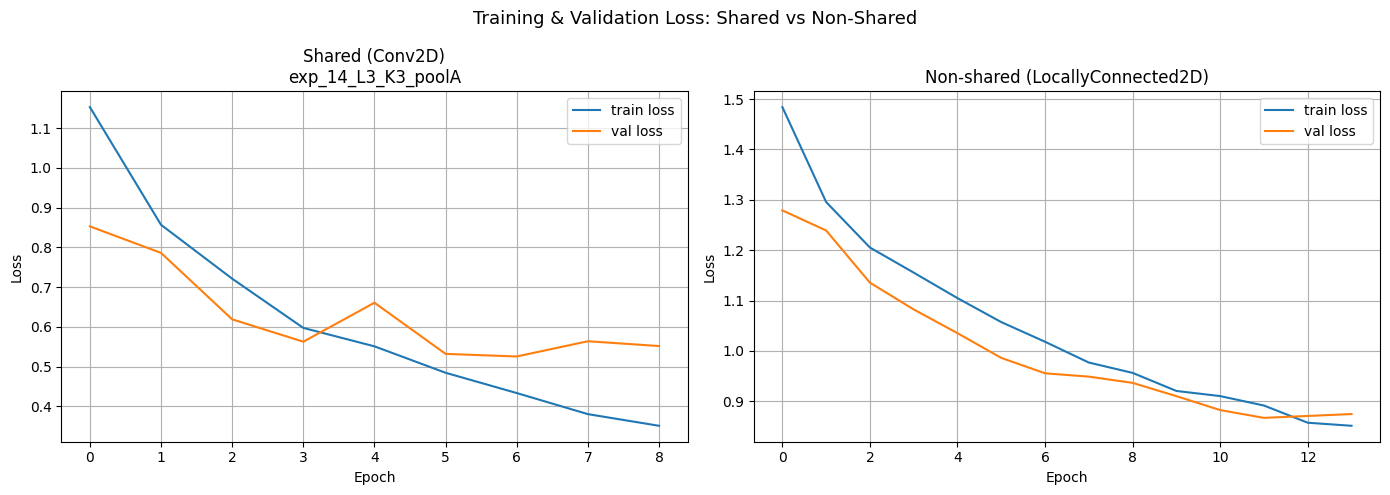

In [72]:
# Plot loss curve: shared vs non-shared
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_cfg["train_loss"], label="train loss")
axes[0].plot(best_cfg["val_loss"],   label="val loss")
axes[0].set_title(f"Shared (Conv2D)\n{best_cfg['tag']}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(lc_hist.history["loss"],     label="train loss")
axes[1].plot(lc_hist.history["val_loss"], label="val loss")
axes[1].set_title("Non-shared (LocallyConnected2D)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Training & Validation Loss: Shared vs Non-Shared", fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "shared_vs_nonshared_loss.png", dpi=150)
plt.show()


## 4F. Pengaruh Jumlah Layer Konvolusi

In [73]:
# tag format: exp_XX_L{num_layers}_K{kernel}_pool{P}
import re

def get_num_layers(tag):
    m = re.search(r'_L(\d+)_', tag)
    return int(m.group(1)) if m else None

groups_layers = {}
for r in experiment_results:
    key = get_num_layers(r["tag"])
    groups_layers.setdefault(key, []).append(r)

# Print tabel F1 per variasi jumlah layer
print(f"{'Tag':40s} {'#Layer':>6} {'test_f1':>8}")
print("-" * 58)
for nlayer in sorted(groups_layers):
    for r in groups_layers[nlayer]:
        print(f"{r['tag']:40s} {nlayer:>6} {r['test_f1_macro']:>8.4f}")
    avg = sum(r['test_f1_macro'] for r in groups_layers[nlayer]) / len(groups_layers[nlayer])
    print(f"  → rata-rata test_f1 (L={nlayer}): {avg:.4f}\n")


Tag                                      #Layer  test_f1
----------------------------------------------------------
exp_01_L2_K3_poolM                            2   0.8071
exp_02_L2_K3_poolA                            2   0.7694
exp_03_L2_K5_poolM                            2   0.7916
exp_04_L2_K5_poolA                            2   0.7540
exp_05_L2_K3_poolM                            2   0.7728
exp_06_L2_K3_poolA                            2   0.7706
exp_07_L2_K5_poolM                            2   0.7570
exp_08_L2_K5_poolA                            2   0.7383
  → rata-rata test_f1 (L=2): 0.7701

exp_09_L3_K3_poolM                            3   0.7793
exp_10_L3_K3_poolA                            3   0.8028
exp_11_L3_K5_poolM                            3   0.8158
exp_12_L3_K5_poolA                            3   0.7963
exp_13_L3_K3_poolM                            3   0.7987
exp_14_L3_K3_poolA                            3   0.8194
exp_15_L3_K5_poolM                            3  

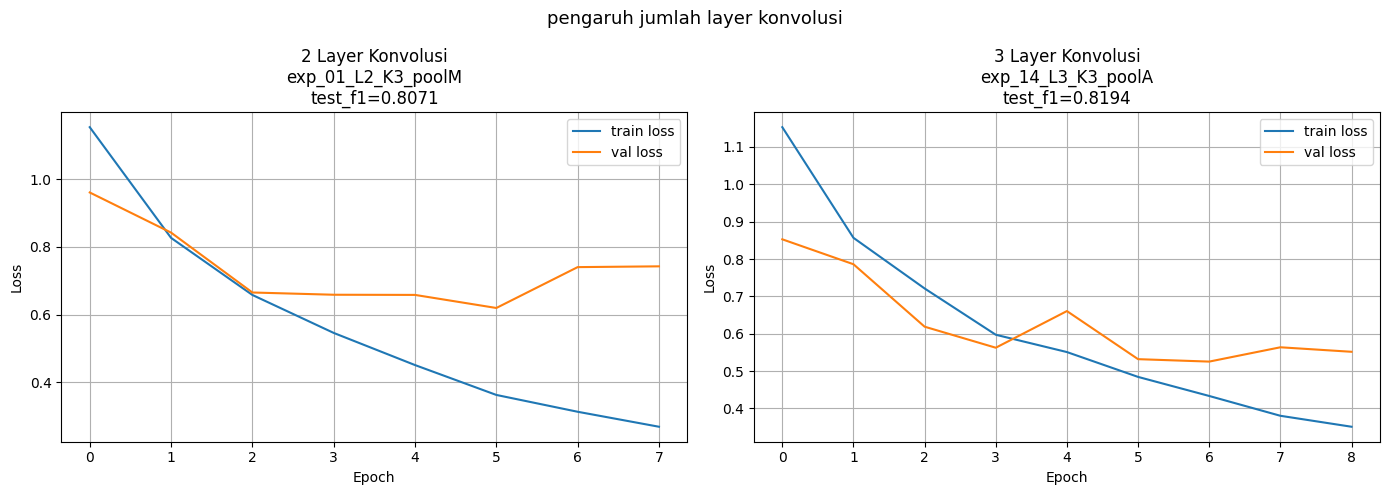

In [74]:
rep = {k: max(v, key=lambda r: r['test_f1_macro']) for k, v in groups_layers.items()}

n_groups = len(rep)
fig, axes = plt.subplots(1, n_groups, figsize=(7 * n_groups, 5))
if n_groups == 1:
    axes = [axes]

for ax, (nlayer, r) in zip(axes, sorted(rep.items())):
    ax.plot(r["train_loss"], label="train loss")
    ax.plot(r["val_loss"],   label="val loss")
    ax.set_title(f"{nlayer} Layer Konvolusi\n{r['tag']}\ntest_f1={r['test_f1_macro']:.4f}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True)

plt.suptitle("pengaruh jumlah layer konvolusi", fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "pengaruh_num_layers.png", dpi=150)
plt.show()


## 4G. Pengaruh Jumlah Filter per Layer

In [75]:
# Filter group: (32,64)/(32,64,128) = 'kecil', (64,128)/(64,128,256) = 'besar'
def get_filter_group(filters):
    # ambil filter pertama sebagai penanda
    return 'kecil' if filters[0] <= 32 else 'besar'

groups_filters = {}
for r in experiment_results:
    key = get_filter_group(r["filters"])
    groups_filters.setdefault(key, []).append(r)

print(f"{'Tag':40s} {'Filter':>18} {'test_f1':>8}")
print("-" * 70)
for fg in sorted(groups_filters):
    for r in groups_filters[fg]:
        print(f"{r['tag']:40s} {str(r['filters']):>18} {r['test_f1_macro']:>8.4f}")
    avg = sum(r['test_f1_macro'] for r in groups_filters[fg]) / len(groups_filters[fg])
    print(f"  → rata-rata test_f1 ({fg}): {avg:.4f}\n")


Tag                                                  Filter  test_f1
----------------------------------------------------------------------
exp_05_L2_K3_poolM                                (64, 128)   0.7728
exp_06_L2_K3_poolA                                (64, 128)   0.7706
exp_07_L2_K5_poolM                                (64, 128)   0.7570
exp_08_L2_K5_poolA                                (64, 128)   0.7383
exp_13_L3_K3_poolM                           (64, 128, 256)   0.7987
exp_14_L3_K3_poolA                           (64, 128, 256)   0.8194
exp_15_L3_K5_poolM                           (64, 128, 256)   0.8111
exp_16_L3_K5_poolA                           (64, 128, 256)   0.7836
  → rata-rata test_f1 (besar): 0.7815

exp_01_L2_K3_poolM                                 (32, 64)   0.8071
exp_02_L2_K3_poolA                                 (32, 64)   0.7694
exp_03_L2_K5_poolM                                 (32, 64)   0.7916
exp_04_L2_K5_poolA                                 (32, 64)   

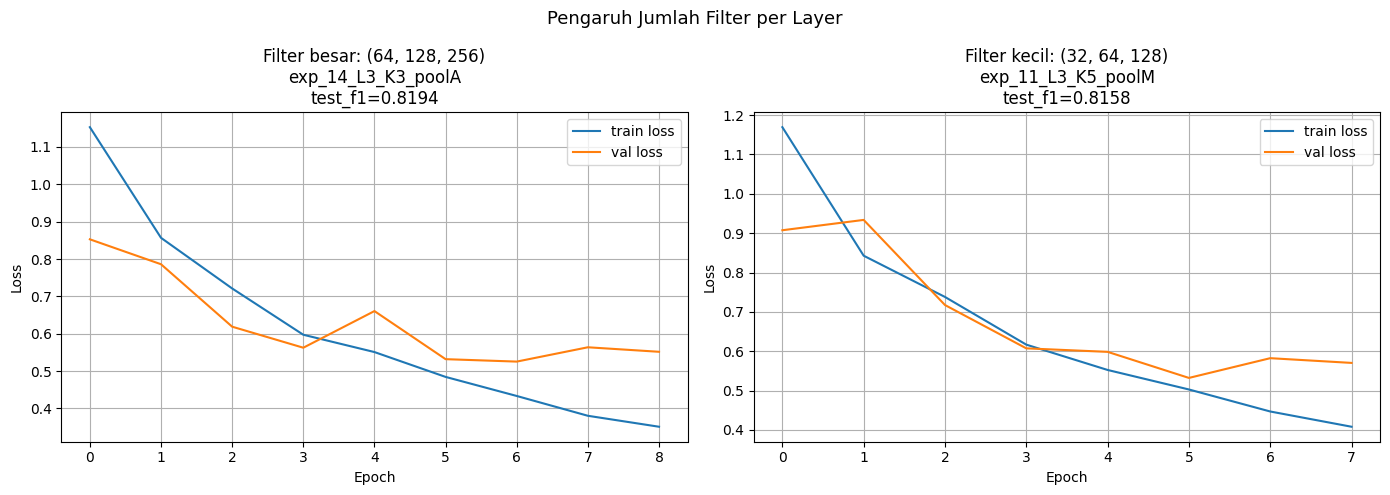

In [76]:
rep_f = {k: max(v, key=lambda r: r['test_f1_macro']) for k, v in groups_filters.items()}

n_groups = len(rep_f)
fig, axes = plt.subplots(1, n_groups, figsize=(7 * n_groups, 5))
if n_groups == 1:
    axes = [axes]

for ax, (fg, r) in zip(axes, sorted(rep_f.items())):
    ax.plot(r["train_loss"], label="train loss")
    ax.plot(r["val_loss"],   label="val loss")
    ax.set_title(f"Filter {fg}: {r['filters']}\n{r['tag']}\ntest_f1={r['test_f1_macro']:.4f}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True)

plt.suptitle("Pengaruh Jumlah Filter per Layer", fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "pengaruh_filters.png", dpi=150)
plt.show()


## 4H. Pengaruh Ukuran Kernel

In [77]:
groups_kernel = {}
for r in experiment_results:
    key = r["kernel_size"]
    groups_kernel.setdefault(key, []).append(r)

print(f"{'Tag':40s} {'Kernel':>6} {'test_f1':>8}")
print("-" * 58)
for ks in sorted(groups_kernel):
    for r in groups_kernel[ks]:
        print(f"{r['tag']:40s} {ks:>6} {r['test_f1_macro']:>8.4f}")
    avg = sum(r['test_f1_macro'] for r in groups_kernel[ks]) / len(groups_kernel[ks])
    print(f"  → rata-rata test_f1 (kernel={ks}): {avg:.4f}\n")


Tag                                      Kernel  test_f1
----------------------------------------------------------
exp_01_L2_K3_poolM                            3   0.8071
exp_02_L2_K3_poolA                            3   0.7694
exp_05_L2_K3_poolM                            3   0.7728
exp_06_L2_K3_poolA                            3   0.7706
exp_09_L3_K3_poolM                            3   0.7793
exp_10_L3_K3_poolA                            3   0.8028
exp_13_L3_K3_poolM                            3   0.7987
exp_14_L3_K3_poolA                            3   0.8194
  → rata-rata test_f1 (kernel=3): 0.7900

exp_03_L2_K5_poolM                            5   0.7916
exp_04_L2_K5_poolA                            5   0.7540
exp_07_L2_K5_poolM                            5   0.7570
exp_08_L2_K5_poolA                            5   0.7383
exp_11_L3_K5_poolM                            5   0.8158
exp_12_L3_K5_poolA                            5   0.7963
exp_15_L3_K5_poolM                          

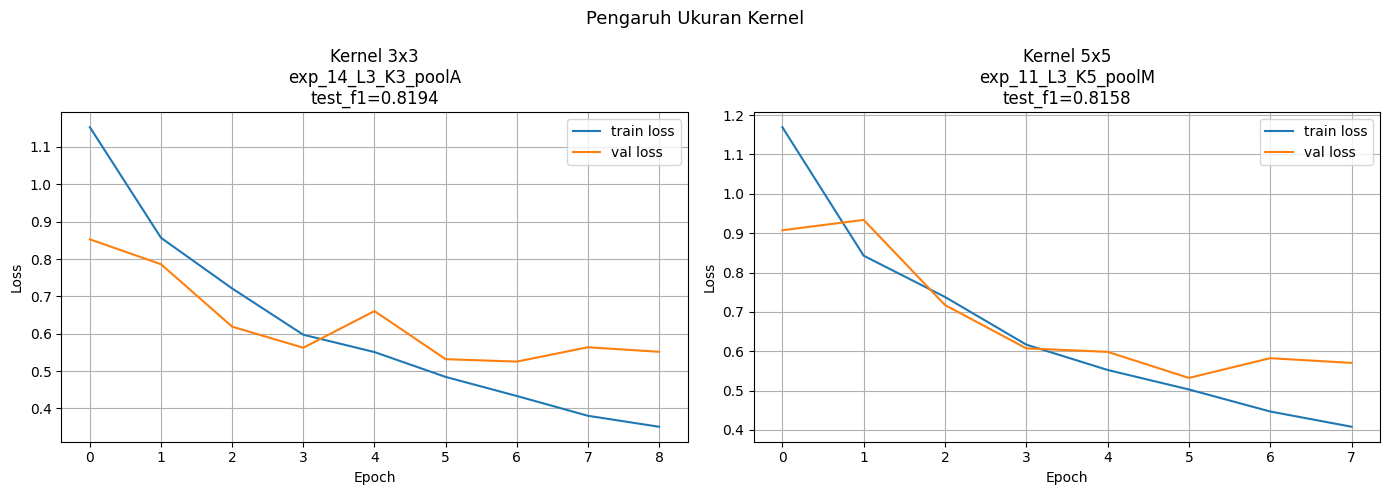

In [78]:
rep_k = {k: max(v, key=lambda r: r['test_f1_macro']) for k, v in groups_kernel.items()}

n_groups = len(rep_k)
fig, axes = plt.subplots(1, n_groups, figsize=(7 * n_groups, 5))
if n_groups == 1:
    axes = [axes]

for ax, (ks, r) in zip(axes, sorted(rep_k.items())):
    ax.plot(r["train_loss"], label="train loss")
    ax.plot(r["val_loss"],   label="val loss")
    ax.set_title(f"Kernel {ks}x{ks}\n{r['tag']}\ntest_f1={r['test_f1_macro']:.4f}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True)

plt.suptitle("Pengaruh Ukuran Kernel", fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "pengaruh_kernel.png", dpi=150)
plt.show()


## 4I. Pengaruh Jenis Pooling Layer

In [79]:
groups_pool = {}
for r in experiment_results:
    key = r["pooling_type"]
    groups_pool.setdefault(key, []).append(r)

print(f"{'Tag':40s} {'Pooling':>8} {'test_f1':>8}")
print("-" * 60)
for pt in sorted(groups_pool):
    for r in groups_pool[pt]:
        print(f"{r['tag']:40s} {pt:>8} {r['test_f1_macro']:>8.4f}")
    avg = sum(r['test_f1_macro'] for r in groups_pool[pt]) / len(groups_pool[pt])
    print(f"  → rata-rata test_f1 (pooling={pt}): {avg:.4f}\n")


Tag                                       Pooling  test_f1
------------------------------------------------------------
exp_02_L2_K3_poolA                            avg   0.7694
exp_04_L2_K5_poolA                            avg   0.7540
exp_06_L2_K3_poolA                            avg   0.7706
exp_08_L2_K5_poolA                            avg   0.7383
exp_10_L3_K3_poolA                            avg   0.8028
exp_12_L3_K5_poolA                            avg   0.7963
exp_14_L3_K3_poolA                            avg   0.8194
exp_16_L3_K5_poolA                            avg   0.7836
  → rata-rata test_f1 (pooling=avg): 0.7793

exp_01_L2_K3_poolM                            max   0.8071
exp_03_L2_K5_poolM                            max   0.7916
exp_05_L2_K3_poolM                            max   0.7728
exp_07_L2_K5_poolM                            max   0.7570
exp_09_L3_K3_poolM                            max   0.7793
exp_11_L3_K5_poolM                            max   0.8158
exp_13_L3

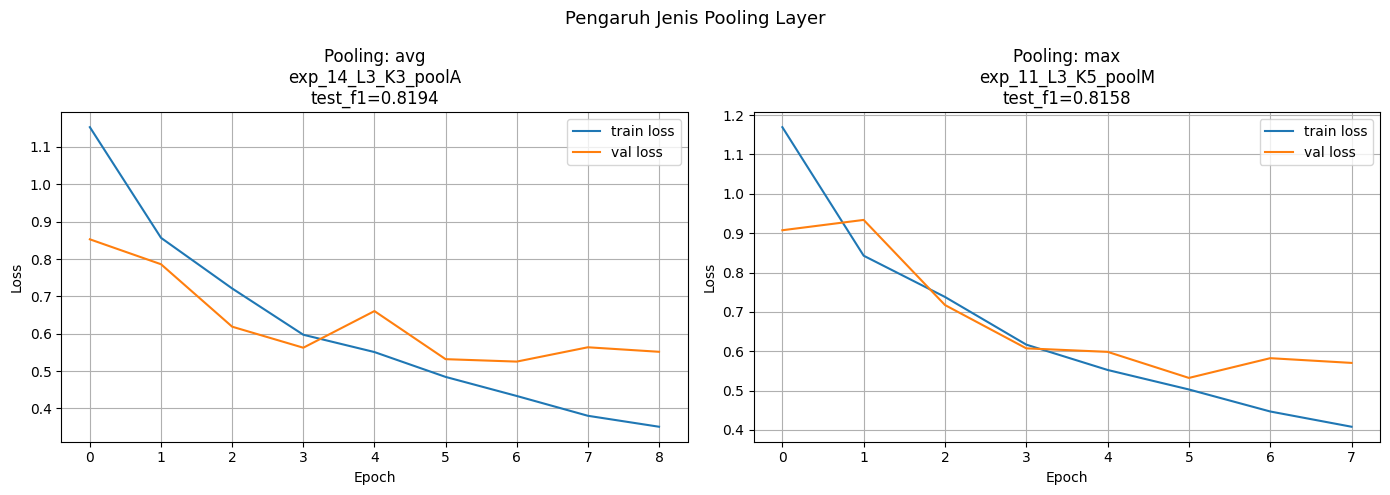

In [80]:
rep_p = {k: max(v, key=lambda r: r['test_f1_macro']) for k, v in groups_pool.items()}

n_groups = len(rep_p)
fig, axes = plt.subplots(1, n_groups, figsize=(7 * n_groups, 5))
if n_groups == 1:
    axes = [axes]

for ax, (pt, r) in zip(axes, sorted(rep_p.items())):
    ax.plot(r["train_loss"], label="train loss")
    ax.plot(r["val_loss"],   label="val loss")
    ax.set_title(f"Pooling: {pt}\n{r['tag']}\ntest_f1={r['test_f1_macro']:.4f}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True)

plt.suptitle("Pengaruh Jenis Pooling Layer", fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "pengaruh_pooling.png", dpi=150)
plt.show()


## 4J. Ringkasan Semua Hasil

In [81]:
df_full = pd.DataFrame(experiment_results).sort_values("test_f1_macro", ascending=False)
display(df_full[[
    "tag", "filters", "kernel_size", "pooling_type",
    "val_acc", "val_f1_macro", "test_f1_macro", "train_time_sec"
]])


,tag,filters,kernel_size,pooling_type,val_acc,val_f1_macro,test_f1_macro,train_time_sec
13,exp_14_L3_K3_poolA,"(64, 128, 256)",3,avg,0.828225,0.830133,0.819436,173.905057
10,exp_11_L3_K5_poolM,"(32, 64, 128)",5,max,0.817890,0.818473,0.815757,127.095176
14,exp_15_L3_K5_poolM,"(64, 128, 256)",5,max,0.814326,0.816154,0.811069,264.299858
0,exp_01_L2_K3_poolM,"(32, 64)",3,max,0.801853,0.804071,0.807133,95.648607
9,exp_10_L3_K3_poolA,"(32, 64, 128)",3,avg,0.815752,0.818557,0.802848,89.930074
12,exp_13_L3_K3_poolM,"(64, 128, 256)",3,max,0.806130,0.808599,0.798730,202.333907
11,exp_12_L3_K5_poolA,"(32, 64, 128)",5,avg,0.800428,0.801519,0.796307,117.473336
2,exp_03_L2_K5_poolM,"(32, 64)",5,max,0.777263,0.779045,0.791642,109.366579
15,exp_16_L3_K5_poolA,"(64, 128, 256)",5,avg,0.777263,0.779045,0.783591,190.855393
8,exp_09_L3_K3_poolM,"(32, 64, 128)",3,max,0.769066,0.772796,0.779251,64.841836


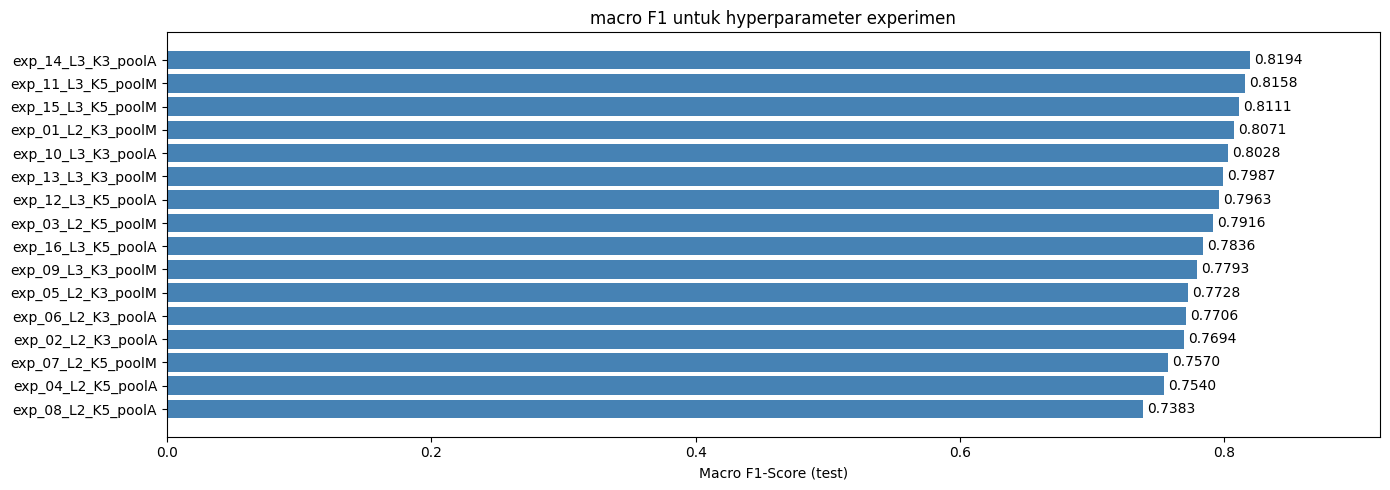

In [83]:
# Bar chart test_f1_macro semua eksperimen
fig, ax = plt.subplots(figsize=(14, 5))
tags   = [r["tag"] for r in sorted(experiment_results, key=lambda r: r["test_f1_macro"], reverse=True)]
scores = [r["test_f1_macro"] for r in sorted(experiment_results, key=lambda r: r["test_f1_macro"], reverse=True)]

bars = ax.barh(tags, scores, color="steelblue")
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_xlabel("Macro F1-Score (test)")
ax.set_title("macro F1 untuk hyperparameter experimen")
ax.set_xlim(0, max(scores) * 1.12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "all_experiments_f1.png", dpi=150)
plt.show()
